# Project Cycle 3 - Extension 2 - Smoking Intensity Trend Analysis Among Female Students

---
## Group Information

**Group:** 24

**Members:**
- 112A50033 王靖慈
- 113370231 王薪崴
---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

pd.set_option("display.max_columns", None)

### Introduction

This extension analysis investigates whether behavioral risk characteristics become more prevalent as smoking intensity increases among female students.

The previous extension analysis compared female smokers and female non-smokers using a binary smoking classification.

This notebook extends the analysis further by examining smoking intensity levels and exploring whether heavier smoking is associated with higher levels of behavioral and psychological risk factors.

The purpose of this extension analysis is to evaluate whether risk behaviors show a trend across increasing smoking intensity groups.

## 2. Load Dataset

In [2]:
# 2. Load Dataset

df = pd.read_csv("../data/raw/YRBS_2007.csv")

print(df.shape)

df.head()

(14041, 103)


,RaceEth,HowOldAreYou,WhatIsYourSex,InWhatGradeAreYou,AreYouHispanicOrLatino,WhatIsYourRace,HowTallAreYouWithoutShoesInMeters,HowMuchDoYouWeighWithoutShoesInKG,BicyleHelmetUse,SeatBeltUse,RidingWithADrinkingDriver,DrinkingAndDriving,WeaponCarrying,GunCarryingPast12Mos,WeaponCarryingAtSchool,SafetyConcernsAtSchool,WereThreatenedOrInjuredWithAWeaponOnSchoolProperty,StolenOrDamagedYourProperty,PhysicalFighting,InjuredIFight,PhysicalFightingAtSchool,BoyfriendGirlfriendPhysicallyHurt,ForcedSexualIntercourse,SadOrHopeless,ConsideredSuicide,MadeASuicidePlan,AttemptedSuicide,InjuriousSuicide,EverCigaretteUse,InitiationSmokingWholeCigarette,CurrentCigaretteUse,SmokedMoreThan10Cigarettes,HowObtainedCigarettes,SmokeOnSchoolProperty,EverSmokedDailyFor30Days,EverSmokingCessation,CurrentSmokelessTobaccoUse,CurrentSmokelessTobaccoOnSchoolProperty,CurrentCigarUse,EverAlcoholUse,InitiationOfAlcoholUse,CurrentAlcoholUse,CurrentBingeDrinking5OrMore,SourceOfAlcohol,DrinkAlcoholOnSchoolProperty,EverMarijuaUse,InitiationOfMarijuaUse,CurrentMarijuaUse,MarijuaOnSchoolProperty,EverCocaineUse,CocaineUsePast30Days,EverInhalantUse,EverHeroinUse,EverMethamphetamineUse,EverEcstasyUse,EverSteriodUse,IllegalInjectedDrugUse,IllegalDrugsAtSchool,EverSexualIntercourse,FirstSexualIntercourse,MultipleSexPartners,CurrentSexualActivity,AlcoholDrugsAndSex,CondomUse,BirthControlPillUse,PerceptionOfWeight,WeightLoss,ExerciseToLoseWeight,ConsumeFewerCaloriesToLoseWeight,FastingToLoseWeight,DietPillsToLoseWeight,LaxativesToLoseWeight,FruitJuiceDrinking,FruitEating,GreenSaladEating,PotatoEating,CarrotEating,OtherVegetableEating,NoSodaDrinking,NoMilkDrinking,PhysicalActivity5OrMoreDays,TelevisionWatching,ComputerUse,PEAttendance,SportsTeamParticipation,TaughtAboutHIV,Asthma,StillHaveAsthma,UsedMotorcycleHelmet,EverUsedLSD,AerobicExercise,NoerobicExercise,MinutesInPEPlayingSports,InjuredWhileExercising,HIVTesting,SunscreenUse,SunProtection,Sleep,HealthInGeneral,BMIPCT,weight,stratum,psu
0,7.0,4.0,2.0,2.0,1.0,C,NaN,NaN,2.0,1.0,5.0,5.0,4.0,3.0,1.0,5.0,6.0,3.0,8.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,7.0,7.0,2.0,3.0,1.0,3.0,5.0,4.0,4.0,NaN,2.0,NaN,4.0,5.0,3.0,NaN,2.0,NaN,NaN,5.0,2.0,4.0,6.0,4.0,4.0,3.0,1.0,2.0,1.0,6.0,5.0,4.0,2.0,3.0,2.0,3.0,3.0,1.0,1.0,2.0,2.0,2.0,5.0,5.0,3.0,2.0,1.0,1.0,7.0,5.0,5.0,4.0,2.0,1.0,1.0,1.0,2.0,3.0,2.0,2.0,6.0,8.0,1.0,3.0,2.0,1.0,1.0,5.0,3.0,NaN,1.5104,101,11030
1,5.0,7.0,2.0,2.0,2.0,E,1.70,68.04,4.0,4.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,2.0,2.0,2.0,2.0,2.0,3.0,3.0,1.0,4.0,NaN,NaN,NaN,NaN,2.0,2.0,7.0,7.0,4.0,4.0,7.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,7.0,7.0,2.0,2.0,2.0,4.0,3.0,1.0,1.0,2.0,2.0,2.0,2.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,6.0,3.0,2.0,2.0,1.0,3.0,4.0,1.0,1.0,2.0,2.0,1.0,2.0,3.0,1.0,5.0,4.0,3.0,66.531824,1.8559,101,11030
2,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,5.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,4.0,5.0,4.0,3.0,4.0,2.0,2.0,1.0,2.0,2.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,4.0,4.0,4.0,4.0,NaN,2.0,2.0,NaN,NaN,6.0,NaN,2.0,2.0,1.0,5.0,5.0,4.0,2.0,4.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,3.0,2.0,2.0,1.0,1.0,2.0,4.0,4.0,2.0,2.0,4.0,2.0,2.0,1.0,3.0,4.0,3.0,3.0,2.0,2.0,2.0,2.0,NaN,3.0,2.0,4.0,4.0,2.0,3.0,2.0,1.0,1.0,1.0,NaN,1.8559,101,11030
3,7.0,1.0,1.0,1.0,1.0,A,1.63,79.38,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,98.174319,1.3264,101,11030
4,7.0,1.0,1.0,5.0,1.0,B,NaN,NaN,6.0,5.0,5.0,NaN,5.0,5.0,5.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN,3.0,7.0,NaN,NaN,NaN,1.0,NaN,1.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,7.0,NaN,N

The YRBS 2007 dataset is loaded from the raw data folder.

Before beginning the analysis, the dataset shape and first few rows are checked to confirm that the file was imported correctly.

## 3. Select Female Students

In [3]:
# 3. Select Female Students

FEMALE_CODE = 1

female_df = df[
    df["WhatIsYourSex"] == FEMALE_CODE
].copy()

print(female_df.shape)

female_df.head()

(7036, 103)


,RaceEth,HowOldAreYou,WhatIsYourSex,InWhatGradeAreYou,AreYouHispanicOrLatino,WhatIsYourRace,HowTallAreYouWithoutShoesInMeters,HowMuchDoYouWeighWithoutShoesInKG,BicyleHelmetUse,SeatBeltUse,RidingWithADrinkingDriver,DrinkingAndDriving,WeaponCarrying,GunCarryingPast12Mos,WeaponCarryingAtSchool,SafetyConcernsAtSchool,WereThreatenedOrInjuredWithAWeaponOnSchoolProperty,StolenOrDamagedYourProperty,PhysicalFighting,InjuredIFight,PhysicalFightingAtSchool,BoyfriendGirlfriendPhysicallyHurt,ForcedSexualIntercourse,SadOrHopeless,ConsideredSuicide,MadeASuicidePlan,AttemptedSuicide,InjuriousSuicide,EverCigaretteUse,InitiationSmokingWholeCigarette,CurrentCigaretteUse,SmokedMoreThan10Cigarettes,HowObtainedCigarettes,SmokeOnSchoolProperty,EverSmokedDailyFor30Days,EverSmokingCessation,CurrentSmokelessTobaccoUse,CurrentSmokelessTobaccoOnSchoolProperty,CurrentCigarUse,EverAlcoholUse,InitiationOfAlcoholUse,CurrentAlcoholUse,CurrentBingeDrinking5OrMore,SourceOfAlcohol,DrinkAlcoholOnSchoolProperty,EverMarijuaUse,InitiationOfMarijuaUse,CurrentMarijuaUse,MarijuaOnSchoolProperty,EverCocaineUse,CocaineUsePast30Days,EverInhalantUse,EverHeroinUse,EverMethamphetamineUse,EverEcstasyUse,EverSteriodUse,IllegalInjectedDrugUse,IllegalDrugsAtSchool,EverSexualIntercourse,FirstSexualIntercourse,MultipleSexPartners,CurrentSexualActivity,AlcoholDrugsAndSex,CondomUse,BirthControlPillUse,PerceptionOfWeight,WeightLoss,ExerciseToLoseWeight,ConsumeFewerCaloriesToLoseWeight,FastingToLoseWeight,DietPillsToLoseWeight,LaxativesToLoseWeight,FruitJuiceDrinking,FruitEating,GreenSaladEating,PotatoEating,CarrotEating,OtherVegetableEating,NoSodaDrinking,NoMilkDrinking,PhysicalActivity5OrMoreDays,TelevisionWatching,ComputerUse,PEAttendance,SportsTeamParticipation,TaughtAboutHIV,Asthma,StillHaveAsthma,UsedMotorcycleHelmet,EverUsedLSD,AerobicExercise,NoerobicExercise,MinutesInPEPlayingSports,InjuredWhileExercising,HIVTesting,SunscreenUse,SunProtection,Sleep,HealthInGeneral,BMIPCT,weight,stratum,psu
3,7.0,1.0,1.0,1.0,1.0,A,1.63,79.38,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,98.174319,1.3264,101,11030
4,7.0,1.0,1.0,5.0,1.0,B,NaN,NaN,6.0,5.0,5.0,NaN,5.0,5.0,5.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN,3.0,7.0,NaN,NaN,NaN,1.0,NaN,1.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,7.0,NaN,NaN,NaN,NaN,NaN,3.0,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.3264,101,11030
5,7.0,6.0,1.0,3.0,1.0,E,1.73,59.42,2.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,2.0,1.0,1.0,1.0,1.0,1.0,2.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,1.0,6.0,2.0,33.075531,1.3507,101,11030
6,5.0,6.0,1.0,3.0,2.0,E,1.78,65.77,1.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,4.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,6.0,3.0,7.0,6.0,2.0,1.0,3.0,1.0,2.0,1.0,1.0,1.0,7.0,2.0,1.0,2.0,2.0,1.0,1.0,5.0,1.0,45.688334,1.5899,101,11030
7,5.0,6.0,1.0,3.0,2.0,E,1.60,56.70,2.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,6.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,4.0,6.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,1.0,1.0,2.0,2.0,2.0,4.0,5.0,1.0,1.0,2.0,2.0,1.0,3.0,6.0,4.0

This notebook focuses only on female students because the objective is to examine smoking intensity patterns within the female population.

## 4. Select Variables

In [4]:
# 4. Select Variables

selected_vars = [
    "CurrentCigaretteUse",
    "CurrentAlcoholUse",
    "CurrentBingeDrinking5OrMore",
    "CurrentMarijuaUse",
    "SadOrHopeless",
    "PhysicalFighting",
    "Sleep"
]

female_trend_df = female_df[
    selected_vars
].copy()

female_trend_df.head()

,CurrentCigaretteUse,CurrentAlcoholUse,CurrentBingeDrinking5OrMore,CurrentMarijuaUse,SadOrHopeless,PhysicalFighting,Sleep
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,NaN,1.0,NaN,1.0,NaN,NaN
5,1.0,1.0,1.0,1.0,2.0,1.0,6.0
6,1.0,1.0,1.0,1.0,2.0,1.0,5.0
7,1.0,1.0,1.0,1.0,2.0,1.0,5.0


The selected variables represent substance-related behaviors, psychological status, externalized risk behavior, and lifestyle patterns.

These variables are used to evaluate whether risk characteristics become more prevalent as smoking intensity increases.

## 5. Missing Value Check

In [5]:
# 5. Missing Value Check

female_trend_df.isnull().sum()

CurrentCigaretteUse            296
CurrentAlcoholUse              611
CurrentBingeDrinking5OrMore    183
CurrentMarijuaUse              150
SadOrHopeless                   96
PhysicalFighting               127
Sleep                          891
dtype: int64

Missing values are inspected before analysis.

As in the previous notebook, missing values will be handled separately within each analysis using pairwise deletion.

## 6. Understand Smoking Intensity Coding

In [6]:
# 6. Understand Smoking Intensity Coding

female_trend_df[
    "CurrentCigaretteUse"
].value_counts(
    dropna=False
).sort_index()

CurrentCigaretteUse
1.0    5573
2.0     356
3.0     168
4.0     111
5.0     129
6.0     100
7.0     303
NaN     296
Name: count, dtype: int64

The CurrentCigaretteUse variable contains multiple categories representing smoking frequency during the past 30 days.

Higher codes indicate more frequent cigarette use.

Therefore, this variable can be used to construct smoking intensity groups.

## 7. Create Smoking Intensity Groups

In [7]:
# 7. Create Smoking Intensity Groups

smoking_map = {
    1: "Non-Smoker",
    2: "Light",
    3: "Light",
    4: "Moderate",
    5: "Moderate",
    6: "Heavy",
    7: "Heavy"
}

female_trend_df["SmokingIntensity"] = (
    female_trend_df["CurrentCigaretteUse"]
    .map(smoking_map)
)

intensity_order = [
    "Non-Smoker",
    "Light",
    "Moderate",
    "Heavy"
]

female_trend_df["SmokingIntensity"] = pd.Categorical(
    female_trend_df["SmokingIntensity"],
    categories=intensity_order,
    ordered=True
)

female_trend_df[
    "SmokingIntensity"
].value_counts(
    dropna=False
)

SmokingIntensity
Non-Smoker    5573
Light          524
Heavy          403
NaN            296
Moderate       240
Name: count, dtype: int64

Female students are divided into four smoking intensity groups.

The order of the smoking intensity variable is manually defined as:

Non-Smoker → Light → Moderate → Heavy

This ordering is important because the purpose of this notebook is to examine whether behavioral risk characteristics increase as smoking intensity becomes higher.

## 8. Save Processed Data

In [8]:
# 8. Save Processed Data

female_trend_df.to_csv(
    "../data/processed/female_smoking_intensity_cleaned.csv",
    index=False
)

print(
    "Processed data exported successfully."
)

Processed data exported successfully.


## 9. Group Size Summary

In [9]:
# 9. Group Size Summary

group_summary = female_trend_df[
    "SmokingIntensity"
].value_counts(
    sort=False
)

group_summary

SmokingIntensity
Non-Smoker    5573
Light          524
Moderate       240
Heavy          403
Name: count, dtype: int64

In [10]:
group_summary.to_csv(
    "../outputs/tables/smoking_intensity_group_size.csv"
)

print("Group size table saved.")

Group size table saved.


The group size summary shows the number of female students in each smoking intensity group.

The groups are displayed in the intended order from non-smokers to heavy smokers.

## 10. Behavioral Trend Analysis

The next step is to examine whether behavioral risk characteristics become more prevalent as smoking intensity increases.

For each behavioral variable, average levels are calculated across smoking intensity groups.

If risk behaviors increase consistently from non-smokers to heavier smokers, this would provide evidence supporting a behavioral risk trend.

In [11]:
# 10. Behavioral Trend Analysis

trend_vars = [
    "CurrentAlcoholUse",
    "CurrentBingeDrinking5OrMore",
    "CurrentMarijuaUse",
    "PhysicalFighting",
    "Sleep"
]

trend_table = (
    female_trend_df
    .groupby(
        "SmokingIntensity",
        observed=True
    )[trend_vars]
    .mean()
    .round(2)
)

trend_table

,CurrentAlcoholUse,CurrentBingeDrinking5OrMore,CurrentMarijuaUse,PhysicalFighting,Sleep
SmokingIntensity,,,,,
Non-Smoker,1.55,1.28,1.16,1.44,3.83
Light,2.76,2.36,1.86,1.83,3.56
Moderate,3.32,2.68,2.24,2.22,3.32
Heavy,3.24,2.84,3.06,2.08,3.07


In [12]:
trend_table.to_csv(
    "../outputs/tables/smoking_intensity_trend_table.csv"
)

print("Trend table saved.")

Trend table saved.


### Interpretation

The behavioral trend table shows clear differences across smoking intensity groups.

Compared with non-smokers, female students in higher smoking intensity groups generally reported higher levels of alcohol use, binge drinking, marijuana use, and physical fighting.

Marijuana use showed the clearest increasing pattern across smoking intensity groups.

Sleep showed the opposite pattern. Average sleep scores decreased as smoking intensity increased, suggesting that heavier smokers tended to report shorter sleep duration.

Overall, the descriptive results suggest that several behavioral risk characteristics become more prevalent as smoking intensity increases.

In [13]:
## 11. Trend Visualization

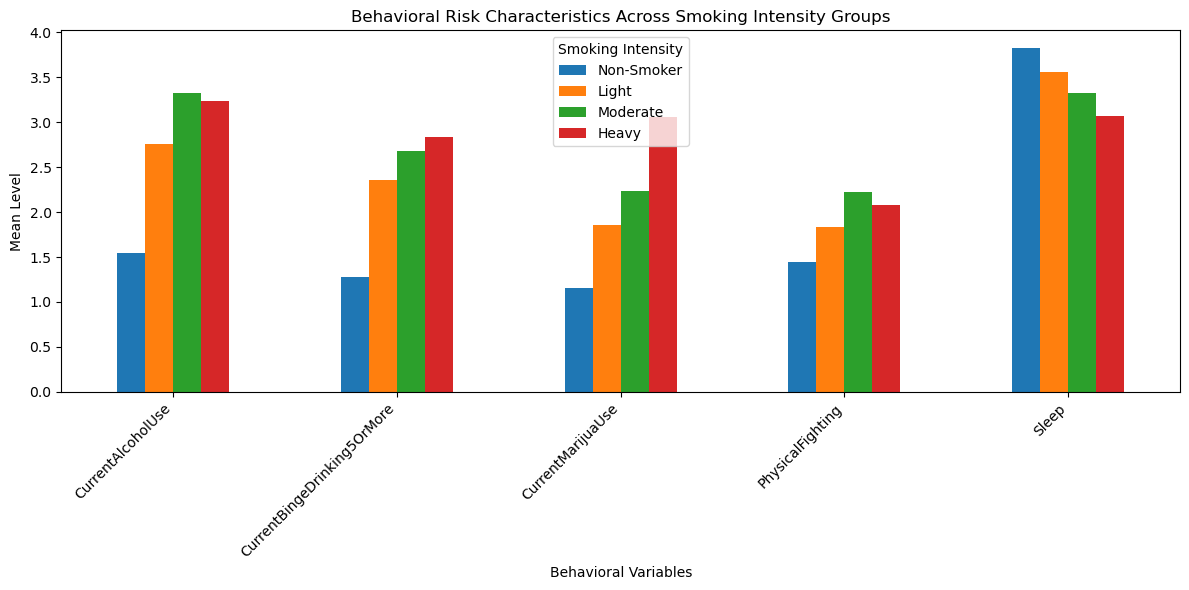

In [14]:
# 11. Trend Visualization

trend_table.T.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Behavioral Risk Characteristics Across Smoking Intensity Groups"
)

plt.ylabel("Mean Level")

plt.xlabel("Behavioral Variables")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Smoking Intensity"
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/smoking_intensity_trend_barplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The grouped bar chart provides an overview of behavioral characteristics across smoking intensity groups.

The smoking intensity groups are ordered from non-smokers to heavy smokers.

The chart shows that female students in higher smoking intensity groups generally had higher average levels of alcohol use, binge drinking, marijuana use, and physical fighting.

Sleep showed a decreasing pattern, indicating that heavier smokers tended to report shorter sleep duration.

### 11.1 Behavioral Trend Line Plot

A line plot is used to visualize behavioral changes across smoking intensity groups.

Because smoking intensity is an ordered variable, a line plot provides a clearer view of trend patterns than a grouped bar chart.

Increasing lines indicate that behavioral risk characteristics become more prevalent as smoking intensity increases.

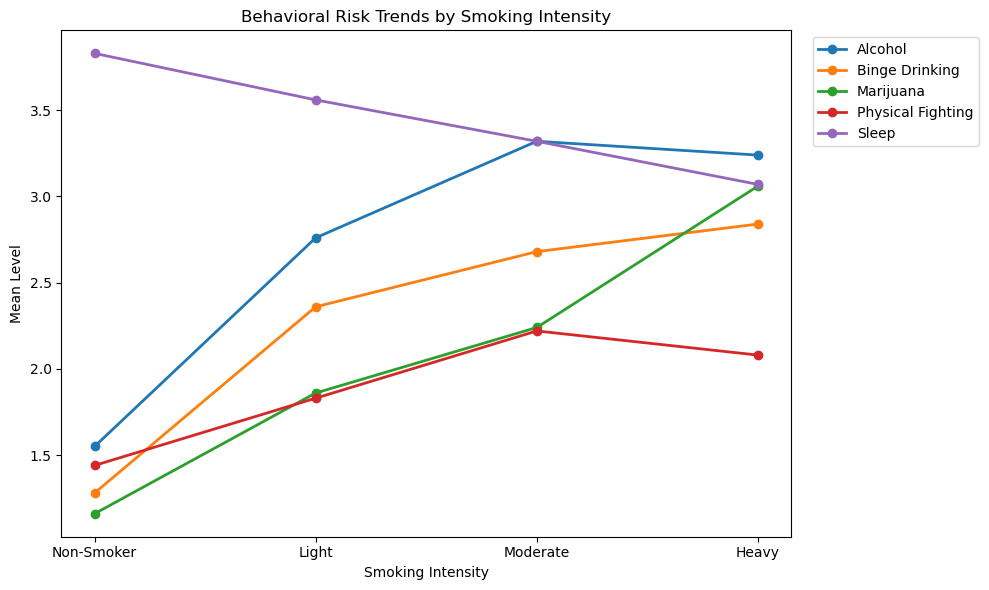

In [15]:
# 11.1 Behavioral Trend Line Plot

line_table = trend_table.copy()

line_table.columns = [
    "Alcohol",
    "Binge Drinking",
    "Marijuana",
    "Physical Fighting",
    "Sleep"
]

plt.figure(figsize=(10, 6))

for var in line_table.columns:

    plt.plot(
        line_table.index,
        line_table[var],
        marker="o",
        linewidth=2,
        label=var
    )

plt.title(
    "Behavioral Risk Trends by Smoking Intensity"
)

plt.xlabel(
    "Smoking Intensity"
)

plt.ylabel(
    "Mean Level"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/smoking_intensity_trend_lineplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The line plot highlights the overall trend of behavioral risk characteristics across smoking intensity groups.

Alcohol use, binge drinking, and marijuana use generally increased as smoking intensity increased.

Marijuana use showed the strongest upward trend from non-smokers to heavy smokers.

Sleep showed the opposite pattern, with average sleep scores decreasing as smoking intensity increased.

These trend patterns provide visual evidence that several behavioral risk characteristics become more prevalent among female students with higher smoking intensity.

## 12. Trend Heatmap

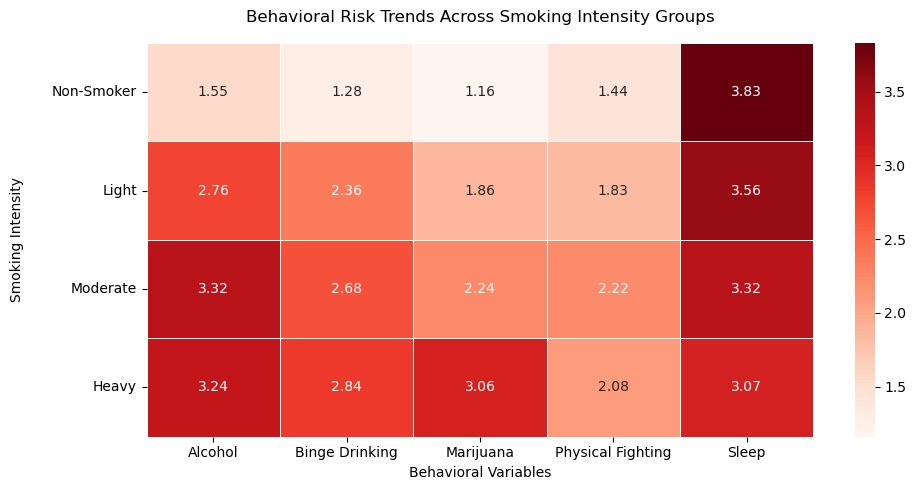

In [16]:
# 12. Trend Heatmap

heatmap_table = trend_table.copy()

heatmap_table.columns = [
    "Alcohol",
    "Binge Drinking",
    "Marijuana",
    "Physical Fighting",
    "Sleep"
]

plt.figure(figsize=(10, 5))

sns.heatmap(
    heatmap_table,
    annot=True,
    cmap="Reds",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Behavioral Risk Trends Across Smoking Intensity Groups",
    pad=15
)

plt.xlabel(
    "Behavioral Variables"
)

plt.ylabel(
    "Smoking Intensity",
    labelpad=20
)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/smoking_intensity_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The heatmap allows behavioral patterns to be compared across smoking intensity groups simultaneously.

The smoking intensity groups are displayed in order from non-smokers to heavy smokers.

Darker colors are concentrated among the moderate and heavy smoking groups for alcohol use, binge drinking, marijuana use, and physical fighting.

In contrast, sleep scores become progressively lower as smoking intensity increases.

The overall pattern suggests that female students with higher smoking intensity tend to exhibit a broader profile of behavioral risk factors.

## 13. SadOrHopeless Analysis

In [17]:
# 13. SadOrHopeless Analysis

sad_table = pd.crosstab(
    female_trend_df["SmokingIntensity"],
    female_trend_df["SadOrHopeless"],
    normalize="index"
) * 100

sad_table = sad_table.reindex(
    intensity_order
)

sad_table.round(2)

SadOrHopeless,1.0,2.0
SmokingIntensity,,
Non-Smoker,32.82,67.18
Light,53.15,46.85
Moderate,56.72,43.28
Heavy,54.25,45.75


In [18]:
sad_table.to_csv(
    "../outputs/tables/smoking_intensity_sadness_table.csv"
)

print("Sadness table saved.")

Sadness table saved.


### Interpretation

In this table:

Code 1 represents Yes.

Code 2 represents No.

Therefore, the percentage under code 1 represents students who reported feeling sad or hopeless during the past 12 months.

Female students in the smoking groups showed higher percentages of sadness or hopelessness than female non-smokers.

These results suggest that smoking intensity is associated with higher prevalence of reported sadness or hopelessness.

## 14. Chi-Square Tests

In [19]:
# 14. Chi-Square Tests

risk_vars = [
    "CurrentAlcoholUse",
    "CurrentBingeDrinking5OrMore",
    "CurrentMarijuaUse",
    "PhysicalFighting",
    "SadOrHopeless"
]

chi_results = []

for var in risk_vars:

    temp_df = female_trend_df[
        ["SmokingIntensity", var]
    ].dropna()

    contingency = pd.crosstab(
        temp_df["SmokingIntensity"],
        temp_df[var]
    )

    contingency = contingency.reindex(
        intensity_order
    )

    chi2, p, dof, expected = chi2_contingency(
        contingency
    )

    chi_results.append({
        "Variable": var,
        "Chi-square": round(chi2, 2),
        "p-value": p
    })

chi_results_df = pd.DataFrame(
    chi_results
)

chi_results_df

,Variable,Chi-square,p-value
0,CurrentAlcoholUse,1720.87,0.000000e+00
1,CurrentBingeDrinking5OrMore,1580.17,0.000000e+00
2,CurrentMarijuaUse,1981.21,0.000000e+00
3,PhysicalFighting,298.78,5.624743e-51
4,SadOrHopeless,190.99,3.722883e-41


In [20]:
chi_results_df[
    "p-value formatted"
] = chi_results_df[
    "p-value"
].apply(
    lambda x:
    "<0.001"
    if x < 0.001
    else round(x, 4)
)

chi_results_df

,Variable,Chi-square,p-value,p-value formatted
0,CurrentAlcoholUse,1720.87,0.000000e+00,<0.001
1,CurrentBingeDrinking5OrMore,1580.17,0.000000e+00,<0.001
2,CurrentMarijuaUse,1981.21,0.000000e+00,<0.001
3,PhysicalFighting,298.78,5.624743e-51,<0.001
4,SadOrHopeless,190.99,3.722883e-41,<0.001


In [21]:
chi_results_df.to_csv(
    "../outputs/tables/chi_square_trend_results.csv",
    index=False
)

print(
    "Chi-square results saved."
)

Chi-square results saved.


### Statistical Interpretation

Chi-square tests were conducted to evaluate whether behavioral risk characteristics were associated with smoking intensity.

All behavioral variables produced p-values below 0.001.

The results indicate statistically significant associations between smoking intensity and alcohol use, binge drinking, marijuana use, physical fighting, and sadness or hopelessness.

These findings suggest that smoking intensity is strongly related to multiple behavioral and psychological risk factors among female students.

## 15. Summary of Findings

This extension analysis examined whether behavioral risk characteristics became more prevalent as smoking intensity increased among female students.

The descriptive results showed that higher smoking intensity groups generally reported higher alcohol use, higher binge drinking frequency, higher marijuana use, higher levels of physical fighting, and higher prevalence of sadness or hopelessness.

Marijuana use and binge drinking showed the clearest increasing trends across smoking intensity groups.

Sleep showed the opposite pattern, with heavier smokers reporting lower average sleep scores, suggesting shorter sleep duration.

Chi-square tests indicated statistically significant associations between smoking intensity and all examined behavioral risk characteristics.

## 16. Final Interpretation

This extension analysis investigated whether behavioral risk characteristics became more prevalent as smoking intensity increased among female students.

The results showed that female students with higher smoking intensity generally reported higher levels of alcohol use, binge drinking, marijuana use, physical fighting, and sadness or hopelessness.

Several behavioral risk characteristics displayed generally increasing trends across smoking intensity groups. Marijuana use showed the strongest trend, while sleep duration showed an inverse relationship with smoking intensity.

Chi-square tests confirmed statistically significant associations between smoking intensity and all examined behavioral and psychological variables.

Overall, the findings suggest that smoking intensity among female students is associated with a broader behavioral risk profile. Female students who reported heavier smoking tended to exhibit multiple co-occurring risk characteristics rather than cigarette use alone.

However, because the YRBS dataset is observational survey data, these findings should be interpreted as associations rather than causal relationships.

This extension analysis extends the previous notebook by showing that risk behaviors are not only more common among female smokers, but also tend to become more prevalent as smoking intensity increases.

## Notebook 3 Completion Checklist

Before finalizing Notebook 3, confirm that the following components are completed:

- Female subset selection
- Variable selection
- Missing value check
- Smoking intensity coding check
- Smoking intensity group creation
- Smoking intensity order setting
- Processed data export
- Group size summary
- Behavioral trend table
- Grouped bar chart
- Trend heatmap
- SadOrHopeless percentage analysis
- Chi-square tests
- Summary of findings
- Final interpretation